# Decompose the fingerprints of subannual, interannual, decadal and multi-decadal change in the SEAPODYM inputs


Purpose
-------

    1.    Decompose the time seriess at each grid cell location into Intrinsic Mode Functions (IMFs) using EMD.
            i)  remove monthly climatology
            ii) remove linear trend over timeseries
    2.    Identify and correlate relevant IMFs with known indices for ENSO and IPO.
    3.    Compute slope of relationship between ENSO/IPO and variable of interest to quantify effect of ENSO/IPO


### IMPORTS

In [2]:

import sys
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from cmocean.tools import lighten
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# oceanographic
import gsw as gsw

# statistics
import scipy as sci
from scipy.signal import hilbert, periodogram
from PyEMD import EMD, CEEMDAN

# regridding package
import xesmf as xe

# Copernicus marine toolbox
#import copernicusmarine
#from pprint import pprint
#copernicusmarine.login()

# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("scipy version =", sci.__version__)
print("xarray version =", xr.__version__)
print("xesmf version =", xe.__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)


wrkdir="/g/data/es60/SEAPODYM"
os.chdir(wrkdir)
os.getcwd()


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
scipy version = 1.15.3
xarray version = 2025.4.0
xesmf version = 0.8.10
cartopy version = 0.24.1
matplotlib version = 3.10.6
cmocean version = v3.0.3


'/g/data/es60/SEAPODYM'

## Load the SEAPODYM forcings

In [3]:
%%time

sst = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_sst_1958_2022.nc")['sst']
mld = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_mld_1958_2022.nc")['mld']
zeu = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_zeu_1958_2022.nc")['zeu']
pp = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_pp_1958_2022.nc")['pp']
pp75 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_pp75_1958_2022.nc")['pp75']
uo = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_uo_1958_2022.nc")['uo']
vo = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_vo_1958_2022.nc")['vo']
T_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L1_1958_2022.nc")['T_L1']
T_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L2_1958_2022.nc")['T_L2']
T_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L3_1958_2022.nc")['T_L3']
O2_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_O2_L1_1958_2022.nc")['O2_L1'] * 44.661
O2_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_O2_L2_1958_2022.nc")['O2_L2'] * 44.661
O2_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_O2_L3_1958_2022.nc")['O2_L3'] * 44.661
U_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_U_L1_1958_2022.nc")['U_L1']
U_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_U_L2_1958_2022.nc")['U_L2']
U_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_U_L3_1958_2022.nc")['U_L3']
V_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_V_L1_1958_2022.nc")['V_L1']
V_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_V_L2_1958_2022.nc")['V_L2']
V_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_V_L3_1958_2022.nc")['V_L3']

larvae = xr.open_dataset("/g/data/es60/SEAPODYM/skipjack_biomass_by_age.nc")['larvae_biomass']
juvenile = xr.open_dataset("/g/data/es60/SEAPODYM/skipjack_biomass_by_age.nc")['juvenile_biomass']
adult = xr.open_dataset("/g/data/es60/SEAPODYM/skipjack_biomass_by_age.nc")['adult_biomass']

lons = sst.coords['lon']
lats = sst.coords['lat']

#sst


CPU times: user 772 ms, sys: 3.46 s, total: 4.24 s
Wall time: 3min 26s


## Calculate the anomalies

CPU times: user 1min 12s, sys: 5.9 s, total: 1min 18s
Wall time: 2min 36s


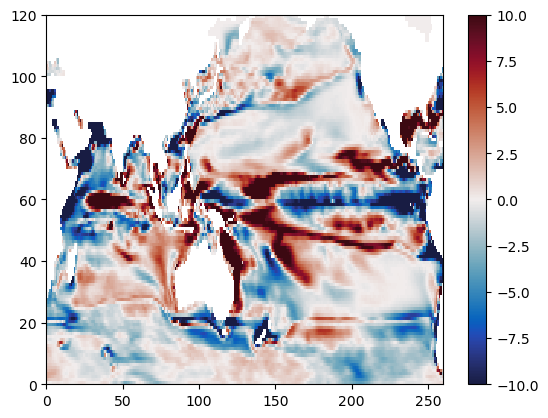

In [4]:
%%time

sst_clim = sst.groupby('time.month').mean('time')
sst_anom = sst.groupby('time.month') - sst_clim
mld_clim = mld.groupby('time.month').mean('time')
mld_anom = mld.groupby('time.month') - mld_clim
zeu_clim = zeu.groupby('time.month').mean('time')
zeu_anom = zeu.groupby('time.month') - zeu_clim
uo_clim = uo.groupby('time.month').mean('time')
uo_anom = uo.groupby('time.month') - uo_clim
vo_clim = vo.groupby('time.month').mean('time')
vo_anom = vo.groupby('time.month') - vo_clim
pp_clim = pp.groupby('time.month').mean('time')
pp_anom = pp.groupby('time.month') - pp_clim
pp75_clim = pp75.groupby('time.month').mean('time')
pp75_anom = pp75.groupby('time.month') - pp75_clim
T_L1_clim = T_L1.groupby('time.month').mean('time')
T_L1_anom = T_L1.groupby('time.month') - T_L1_clim
T_L2_clim = T_L2.groupby('time.month').mean('time')
T_L2_anom = T_L2.groupby('time.month') - T_L2_clim
T_L3_clim = T_L3.groupby('time.month').mean('time')
T_L3_anom = T_L3.groupby('time.month') - T_L3_clim
O2_L1_clim = O2_L1.groupby('time.month').mean('time')
O2_L1_anom = O2_L1.groupby('time.month') - O2_L1_clim
O2_L2_clim = O2_L2.groupby('time.month').mean('time')
O2_L2_anom = O2_L2.groupby('time.month') - O2_L2_clim
O2_L3_clim = O2_L3.groupby('time.month').mean('time')
O2_L3_anom = O2_L3.groupby('time.month') - O2_L3_clim
U_L1_clim = U_L1.groupby('time.month').mean('time')
U_L1_anom = U_L1.groupby('time.month') - U_L1_clim
U_L2_clim = U_L2.groupby('time.month').mean('time')
U_L2_anom = U_L2.groupby('time.month') - U_L2_clim
U_L3_clim = U_L3.groupby('time.month').mean('time')
U_L3_anom = U_L3.groupby('time.month') - U_L3_clim
V_L1_clim = V_L1.groupby('time.month').mean('time')
V_L1_anom = V_L1.groupby('time.month') - V_L1_clim
V_L2_clim = V_L2.groupby('time.month').mean('time')
V_L2_anom = V_L2.groupby('time.month') - V_L2_clim
V_L3_clim = V_L3.groupby('time.month').mean('time')
V_L3_anom = V_L3.groupby('time.month') - V_L3_clim
larvae_clim = larvae.groupby('time.month').mean('time')
larvae_anom = larvae.groupby('time.month') - larvae_clim
juvenile_clim = juvenile.groupby('time.month').mean('time')
juvenile_anom = juvenile.groupby('time.month') - juvenile_clim
adult_clim = adult.groupby('time.month').mean('time')
adult_anom = adult.groupby('time.month') - adult_clim


plt.figure()
plt.pcolormesh(pp_anom.isel(time=0), cmap=cmo.balance, vmin=-10, vmax=10)
plt.colorbar()


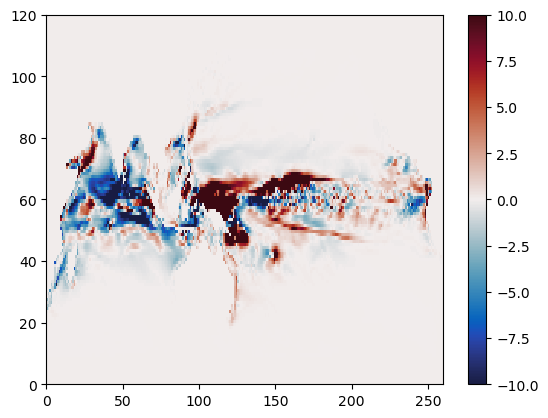

In [7]:
plt.figure()
plt.pcolormesh(larvae_anom.isel(time=0), cmap=cmo.balance, vmin=-10, vmax=10)
plt.colorbar()

## detrend the datasets

In [8]:
%%time

### remove global trend
def detrend_1d(arr):
    """Remove the linear trend from a 1D array."""
    x = np.arange(len(arr))
    # Fit a linear trend
    coeffs = np.polyfit(x, arr, 1)
    trend = np.polyval(coeffs, x)
    # Remove the trend
    detrended = arr - trend
    return detrended

sst_detr = xr.apply_ufunc(
    detrend_1d,
    sst_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[sst_anom.dtype]
)

mld_detr = xr.apply_ufunc(
    detrend_1d,
    mld_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[mld_anom.dtype]
)

zeu_detr = xr.apply_ufunc(
    detrend_1d,
    zeu_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[zeu_anom.dtype]
)

pp_detr = xr.apply_ufunc(
    detrend_1d,
    pp_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[pp_anom.dtype]
)

pp75_detr = xr.apply_ufunc(
    detrend_1d,
    pp75_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[pp75_anom.dtype]
)

uo_detr = xr.apply_ufunc(
    detrend_1d,
    uo_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[uo_anom.dtype]
)

vo_detr = xr.apply_ufunc(
    detrend_1d,
    vo_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[vo_anom.dtype]
)

T_L1_detr = xr.apply_ufunc(
    detrend_1d,
    T_L1_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[T_L1_anom.dtype]
)
T_L2_detr = xr.apply_ufunc(
    detrend_1d,
    T_L2_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[T_L2_anom.dtype]
)
T_L3_detr = xr.apply_ufunc(
    detrend_1d,
    T_L3_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[T_L3_anom.dtype]
)

U_L1_detr = xr.apply_ufunc(
    detrend_1d,
    U_L1_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[U_L1_anom.dtype]
)
U_L2_detr = xr.apply_ufunc(
    detrend_1d,
    U_L2_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[U_L2_anom.dtype]
)
U_L3_detr = xr.apply_ufunc(
    detrend_1d,
    U_L3_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[U_L3_anom.dtype]
)
V_L1_detr = xr.apply_ufunc(
    detrend_1d,
    V_L1_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[V_L1_anom.dtype]
)
V_L2_detr = xr.apply_ufunc(
    detrend_1d,
    V_L2_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[V_L2_anom.dtype]
)
V_L3_detr = xr.apply_ufunc(
    detrend_1d,
    V_L3_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[V_L3_anom.dtype]
)

O2_L1_detr = xr.apply_ufunc(
    detrend_1d,
    O2_L1_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[O2_L1_anom.dtype]
)
O2_L2_detr = xr.apply_ufunc(
    detrend_1d,
    O2_L2_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[O2_L2_anom.dtype]
)
O2_L3_detr = xr.apply_ufunc(
    detrend_1d,
    O2_L3_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[O2_L3_anom.dtype]
)


larvae_detr = xr.apply_ufunc(
    detrend_1d,
    larvae_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[larvae_anom.dtype]
)
juvenile_detr = xr.apply_ufunc(
    detrend_1d,
    juvenile_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[juvenile_anom.dtype]
)
adult_detr = xr.apply_ufunc(
    detrend_1d,
    adult_anom,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[adult_anom.dtype]
)



CPU times: user 1min 40s, sys: 585 ms, total: 1min 40s
Wall time: 1min 40s


## determine the linear trends since 1958

In [10]:
%%time

### retrive the linear least squares trend
sst_trend = sst_anom - sst_detr
mld_trend = mld_anom - mld_detr
zeu_trend = zeu_anom - zeu_detr
pp_trend = pp_anom - pp_detr
pp75_trend = pp75_anom - pp75_detr
uo_trend = uo_anom - uo_detr
vo_trend = vo_anom - vo_detr
T_L1_trend = T_L1_anom - T_L1_detr
T_L2_trend = T_L2_anom - T_L2_detr
T_L3_trend = T_L3_anom - T_L3_detr
O2_L1_trend = O2_L1_anom - O2_L1_detr
O2_L2_trend = O2_L2_anom - O2_L2_detr
O2_L3_trend = O2_L3_anom - O2_L3_detr
U_L1_trend = U_L1_anom - U_L1_detr
U_L2_trend = U_L2_anom - U_L2_detr
U_L3_trend = U_L3_anom - U_L3_detr
V_L1_trend = V_L1_anom - V_L1_detr
V_L2_trend = V_L2_anom - V_L2_detr
V_L3_trend = V_L3_anom - V_L3_detr
larvae_trend = larvae_anom - larvae_detr
juvenile_trend = juvenile_anom - juvenile_detr
adult_trend = adult_anom - adult_detr



CPU times: user 2.6 s, sys: 566 ms, total: 3.16 s
Wall time: 3.16 s


In [11]:
%%time

### since the trends are linear, they can be described by one number (their slope)
### calculate the slope on a decadal timescale
dates = mld.coords['time']
sst_trend = sst_trend.sel(time=dates[-1]) - sst_trend.sel(time=dates[0]) / len(dates) * 12 * 10
mld_trend = mld_trend.sel(time=dates[-1]) - mld_trend.sel(time=dates[0]) / len(dates) * 12 * 10
zeu_trend = zeu_trend.sel(time=dates[-1]) - zeu_trend.sel(time=dates[0]) / len(dates) * 12 * 10
pp_trend = pp_trend.sel(time=dates[-1]) - pp_trend.sel(time=dates[0]) / len(dates) * 12 * 10
pp75_trend = pp75_trend.sel(time=dates[-1]) - pp75_trend.sel(time=dates[0]) / len(dates) * 12 * 10
uo_trend = uo_trend.sel(time=dates[-1]) - uo_trend.sel(time=dates[0]) / len(dates) * 12 * 10
vo_trend = vo_trend.sel(time=dates[-1]) - vo_trend.sel(time=dates[0]) / len(dates) * 12 * 10
T_L1_trend = T_L1_trend.sel(time=dates[-1]) - T_L1_trend.sel(time=dates[0]) / len(dates) * 12 * 10
T_L2_trend = T_L2_trend.sel(time=dates[-1]) - T_L2_trend.sel(time=dates[0]) / len(dates) * 12 * 10
T_L3_trend = T_L3_trend.sel(time=dates[-1]) - T_L3_trend.sel(time=dates[0]) / len(dates) * 12 * 10
O2_L1_trend = O2_L1_trend.sel(time=dates[-1]) - O2_L1_trend.sel(time=dates[0]) / len(dates) * 12 * 10
O2_L2_trend = O2_L2_trend.sel(time=dates[-1]) - O2_L2_trend.sel(time=dates[0]) / len(dates) * 12 * 10
O2_L3_trend = O2_L3_trend.sel(time=dates[-1]) - O2_L3_trend.sel(time=dates[0]) / len(dates) * 12 * 10
U_L1_trend = U_L1_trend.sel(time=dates[-1]) - U_L1_trend.sel(time=dates[0]) / len(dates) * 12 * 10
U_L2_trend = U_L2_trend.sel(time=dates[-1]) - U_L2_trend.sel(time=dates[0]) / len(dates) * 12 * 10
U_L3_trend = U_L3_trend.sel(time=dates[-1]) - U_L3_trend.sel(time=dates[0]) / len(dates) * 12 * 10
V_L1_trend = V_L1_trend.sel(time=dates[-1]) - V_L1_trend.sel(time=dates[0]) / len(dates) * 12 * 10
V_L2_trend = V_L2_trend.sel(time=dates[-1]) - V_L2_trend.sel(time=dates[0]) / len(dates) * 12 * 10
V_L3_trend = V_L3_trend.sel(time=dates[-1]) - V_L3_trend.sel(time=dates[0]) / len(dates) * 12 * 10



CPU times: user 98.2 ms, sys: 10.8 ms, total: 109 ms
Wall time: 107 ms


In [12]:
%%time

dates = larvae.coords['time']

larvae_trend = larvae_trend.sel(time=dates[-1]) - larvae_trend.sel(time=dates[0]) / len(dates) * 12 * 10
juvenile_trend = juvenile_trend.sel(time=dates[-1]) - juvenile_trend.sel(time=dates[0]) / len(dates) * 12 * 10
adult_trend = adult_trend.sel(time=dates[-1]) - adult_trend.sel(time=dates[0]) / len(dates) * 12 * 10


CPU times: user 24.5 ms, sys: 2.59 ms, total: 27.1 ms
Wall time: 25.3 ms


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 22.2 s, sys: 36.9 ms, total: 22.2 s
Wall time: 22.2 s


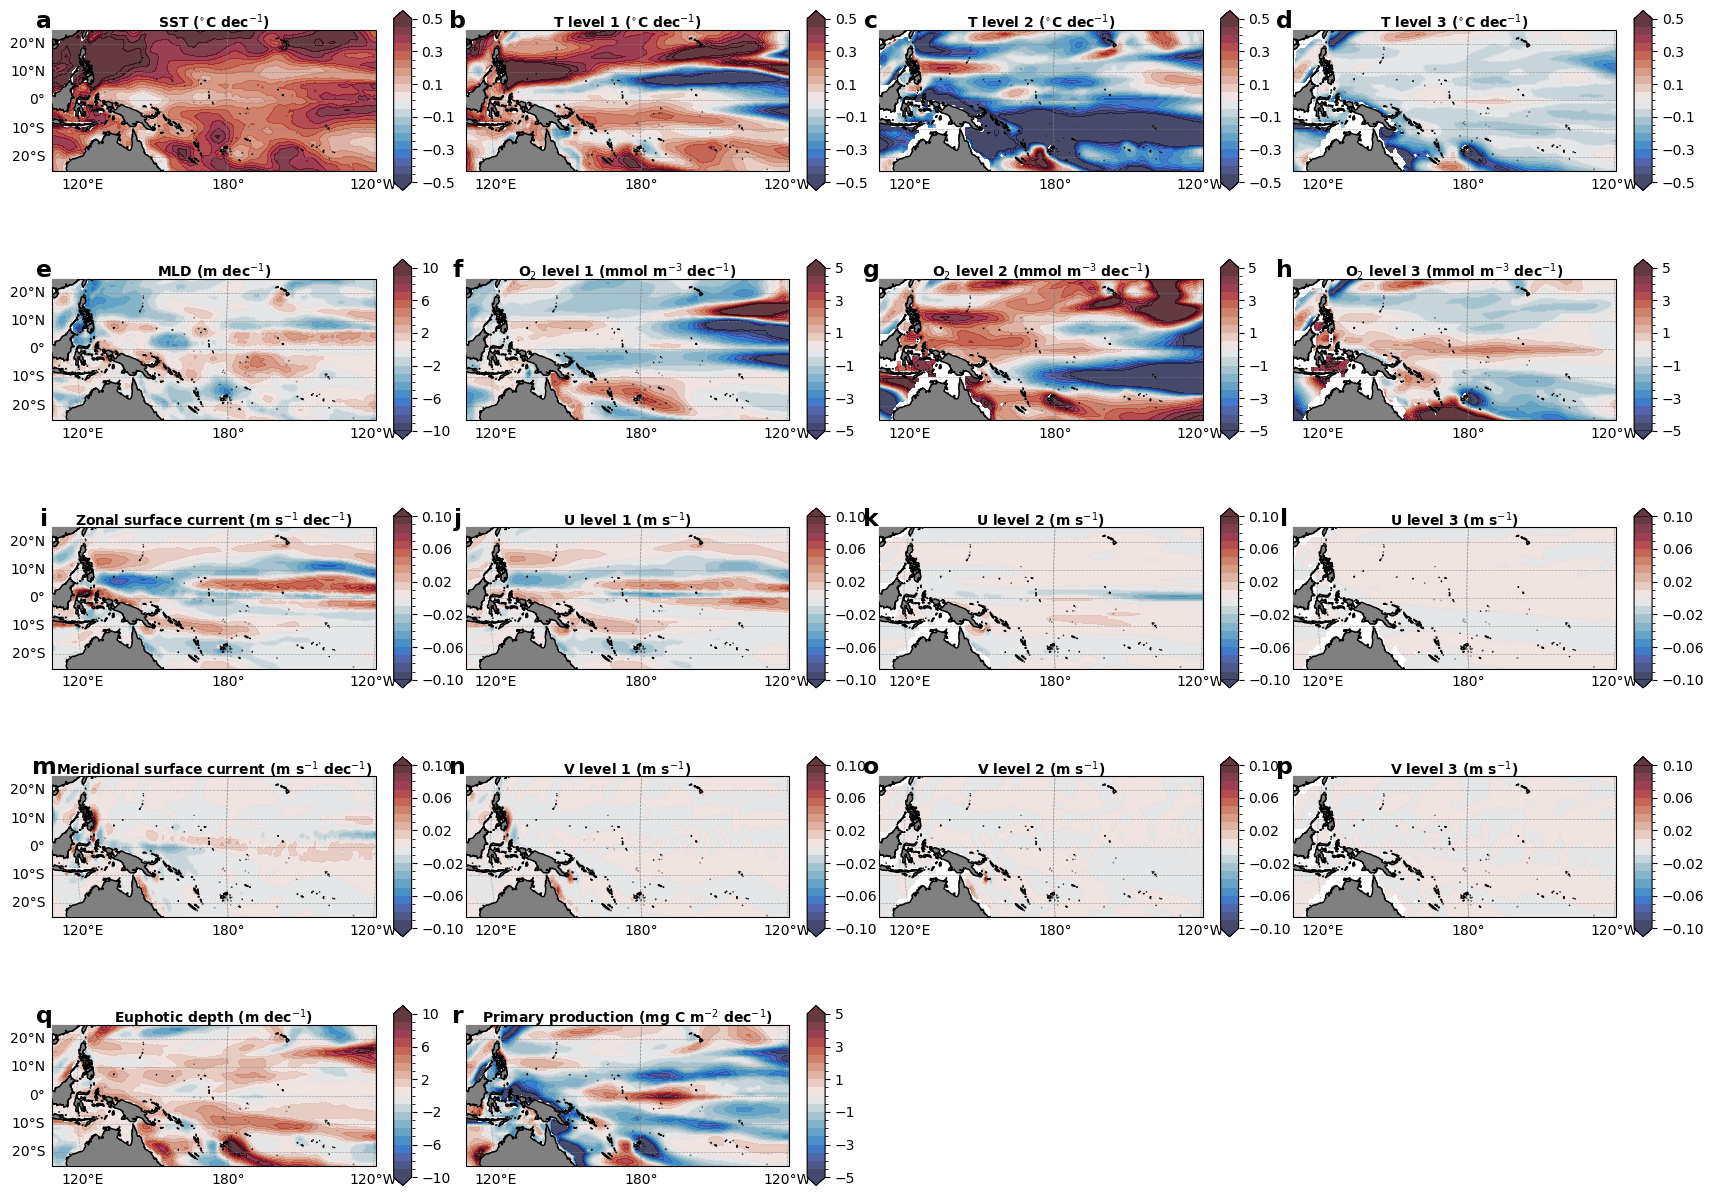

In [16]:
%%time

fslab = 15
fstic = 13

import matplotlib.lines as mlines
from cartopy.util import add_cyclic_point

proj = ccrs.Robinson(central_longitude=205)

colmap1 = lighten(cmo.balance, 0.8) #SST
colmap2 = lighten(cmo.balance, 0.8) #T1
colmap3 = lighten(cmo.balance, 0.8) #T2
colmap4 = lighten(cmo.balance, 0.8) #T3
colmap5 = lighten(cmo.balance, 0.8) #MLD
colmap6 = lighten(cmo.balance, 0.8) #O1
colmap7 = lighten(cmo.balance, 0.8) #O2
colmap8 = lighten(cmo.balance, 0.8) #O3
colmap9 = lighten(cmo.balance, 0.8) #U
colmap10 = lighten(cmo.balance, 0.8) #U1
colmap11 = lighten(cmo.balance, 0.8) #U2
colmap12 = lighten(cmo.balance, 0.8) #U3
colmap13 = lighten(cmo.balance, 0.8) #V
colmap14 = lighten(cmo.balance, 0.8) #V1
colmap15 = lighten(cmo.balance, 0.8) #V2
colmap16 = lighten(cmo.balance, 0.8) #V3
colmap17 = lighten(cmo.balance, 0.8) #ZEU
colmap18 = lighten(cmo.balance, 0.8) #PP

levs1 = np.arange(-0.5,0.51,0.05)
levs2 = np.arange(-0.5,0.51,0.05)
levs3 = np.arange(-0.5,0.51,0.05)
levs4 = np.arange(-0.5,0.51,0.05)
levs5 = np.arange(-10,11,1)
levs6 = np.arange(-5,5.1,0.5)
levs7 = np.arange(-5,5.1,0.5)
levs8 = np.arange(-5,5.1,0.5)
levs9 = np.arange(-0.1,0.11,0.01)
levs10 = np.arange(-0.1,0.11,0.01)
levs11 = np.arange(-0.1,0.11,0.01)
levs12 = np.arange(-0.1,0.11,0.01)
levs13 = np.arange(-0.1,0.11,0.01)
levs14 = np.arange(-0.1,0.11,0.01)
levs15 = np.arange(-0.1,0.11,0.01)
levs16 = np.arange(-0.1,0.11,0.01)
levs17 = np.arange(-10,11,1)
levs18 = np.arange(-5,5.1,0.5)


norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)
norm3 = mcolors.BoundaryNorm(levs3, ncolors=256)
norm4 = mcolors.BoundaryNorm(levs4, ncolors=256)
norm5 = mcolors.BoundaryNorm(levs5, ncolors=256)
norm6 = mcolors.BoundaryNorm(levs6, ncolors=256)
norm7 = mcolors.BoundaryNorm(levs7, ncolors=256)
norm8 = mcolors.BoundaryNorm(levs8, ncolors=256)
norm9 = mcolors.BoundaryNorm(levs9, ncolors=256)
norm10 = mcolors.BoundaryNorm(levs10, ncolors=256)
norm11 = mcolors.BoundaryNorm(levs11, ncolors=256)
norm12 = mcolors.BoundaryNorm(levs12, ncolors=256)
norm13 = mcolors.BoundaryNorm(levs13, ncolors=256)
norm14 = mcolors.BoundaryNorm(levs14, ncolors=256)
norm15 = mcolors.BoundaryNorm(levs15, ncolors=256)
norm16 = mcolors.BoundaryNorm(levs16, ncolors=256)
norm17 = mcolors.BoundaryNorm(levs17, ncolors=256)
norm18 = mcolors.BoundaryNorm(levs18, ncolors=256)


fig = plt.figure(figsize=(20,16))
gs = GridSpec(5, 4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)
ax13 = plt.subplot(gs[3,0], projection=proj)
ax14 = plt.subplot(gs[3,1], projection=proj)
ax15 = plt.subplot(gs[3,2], projection=proj)
ax16 = plt.subplot(gs[3,3], projection=proj)
ax17 = plt.subplot(gs[4,0], projection=proj)
ax18 = plt.subplot(gs[4,1], projection=proj)


p1 = ax1.contourf(lons, lats, sst_trend, transform=ccrs.PlateCarree(), cmap=colmap1, norm=norm1, levels=levs1, extend='both')
p2 = ax2.contourf(lons, lats, T_L1_trend, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm2, levels=levs2, extend='both')
p3 = ax3.contourf(lons, lats, T_L2_trend, transform=ccrs.PlateCarree(), cmap=colmap3, norm=norm3, levels=levs3, extend='both')
p4 = ax4.contourf(lons, lats, T_L3_trend, transform=ccrs.PlateCarree(), cmap=colmap4, norm=norm4, levels=levs4, extend='both')
p5 = ax5.contourf(lons, lats, mld_trend, transform=ccrs.PlateCarree(), cmap=colmap5, norm=norm5, levels=levs5, extend='both')
p6 = ax6.contourf(lons, lats, O2_L1_trend, transform=ccrs.PlateCarree(), cmap=colmap6, norm=norm6, levels=levs6, extend='both')
p7 = ax7.contourf(lons, lats, O2_L2_trend, transform=ccrs.PlateCarree(), cmap=colmap7, norm=norm7, levels=levs7, extend='both')
p8 = ax8.contourf(lons, lats, O2_L3_trend, transform=ccrs.PlateCarree(), cmap=colmap8, norm=norm8, levels=levs8, extend='both')
p9 = ax9.contourf(lons, lats, uo_trend, transform=ccrs.PlateCarree(), cmap=colmap9, norm=norm9, levels=levs9, extend='both')
p10 = ax10.contourf(lons, lats, U_L1_trend, transform=ccrs.PlateCarree(), cmap=colmap10, norm=norm10, levels=levs10, extend='both')
p11 = ax11.contourf(lons, lats, U_L2_trend, transform=ccrs.PlateCarree(), cmap=colmap11, norm=norm11, levels=levs11, extend='both')
p12 = ax12.contourf(lons, lats, U_L3_trend, transform=ccrs.PlateCarree(), cmap=colmap12, norm=norm12, levels=levs12, extend='both')
p13 = ax13.contourf(lons, lats, vo_trend, transform=ccrs.PlateCarree(), cmap=colmap13, norm=norm13, levels=levs13, extend='both')
p14 = ax14.contourf(lons, lats, V_L1_trend, transform=ccrs.PlateCarree(), cmap=colmap14, norm=norm14, levels=levs14, extend='both')
p15 = ax15.contourf(lons, lats, V_L2_trend, transform=ccrs.PlateCarree(), cmap=colmap15, norm=norm15, levels=levs15, extend='both')
p16 = ax16.contourf(lons, lats, V_L3_trend, transform=ccrs.PlateCarree(), cmap=colmap16, norm=norm16, levels=levs16, extend='both')
p17 = ax17.contourf(lons, lats, zeu_trend, transform=ccrs.PlateCarree(), cmap=colmap17, norm=norm17, levels=levs17, extend='both')
p18 = ax18.contourf(lons, lats, pp_trend, transform=ccrs.PlateCarree(), cmap=colmap18, norm=norm18, levels=levs18, extend='both')


ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax13.add_feature(cfeature.LAND, color='grey', zorder=3)
ax13.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax14.add_feature(cfeature.LAND, color='grey', zorder=3)
ax14.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax15.add_feature(cfeature.LAND, color='grey', zorder=3)
ax15.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax16.add_feature(cfeature.LAND, color='grey', zorder=3)
ax16.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax17.add_feature(cfeature.LAND, color='grey', zorder=3)
ax17.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax18.add_feature(cfeature.LAND, color='grey', zorder=3)
ax18.add_feature(cfeature.COASTLINE, color='k', zorder=4)

xx = 0.5; yy = 1.05
plt.text(xx,yy, 'SST ($^{\circ}$C dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy, 'T level 1 ($^{\circ}$C dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy, 'T level 2 ($^{\circ}$C dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax3.transAxes)
plt.text(xx,yy, 'T level 3 ($^{\circ}$C dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax4.transAxes)
plt.text(xx,yy, 'MLD (m dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax5.transAxes)
plt.text(xx,yy, 'O$_2$ level 1 (mmol m$^{-3}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax6.transAxes)
plt.text(xx,yy, 'O$_2$ level 2 (mmol m$^{-3}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax7.transAxes)
plt.text(xx,yy, 'O$_2$ level 3 (mmol m$^{-3}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax8.transAxes)
plt.text(xx,yy, 'Zonal surface current (m s$^{-1}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax9.transAxes)
plt.text(xx,yy, 'U level 1 (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax10.transAxes)
plt.text(xx,yy, 'U level 2 (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax11.transAxes)
plt.text(xx,yy, 'U level 3 (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax12.transAxes)
plt.text(xx,yy, 'Meridional surface current (m s$^{-1}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax13.transAxes)
plt.text(xx,yy, 'V level 1 (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax14.transAxes)
plt.text(xx,yy, 'V level 2 (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax15.transAxes)
plt.text(xx,yy, 'V level 3 (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax16.transAxes)
plt.text(xx,yy, 'Euphotic depth (m dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax17.transAxes)
plt.text(xx,yy, 'Primary production (mg C m$^{-2}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax18.transAxes)

xx = -0.025
yy = 1.06
plt.text(xx,yy, 'a', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy, 'd', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy, 'f', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy, 'g', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy, 'h', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax8.transAxes)
plt.text(xx,yy, 'i', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy, 'j', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy, 'k', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy, 'l', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax12.transAxes)
plt.text(xx,yy, 'm', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax13.transAxes)
plt.text(xx,yy, 'n', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax14.transAxes)
plt.text(xx,yy, 'o', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax15.transAxes)
plt.text(xx,yy, 'p', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax16.transAxes)
plt.text(xx,yy, 'q', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax17.transAxes)
plt.text(xx,yy, 'r', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax18.transAxes)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl13 = ax13.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl14 = ax14.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl15 = ax15.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl16 = ax16.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl17 = ax17.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl18 = ax18.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False
gl13.top_labels = False; gl13.right_labels = False
gl14.top_labels = False; gl14.right_labels = False; gl14.left_labels = False
gl15.top_labels = False; gl15.right_labels = False; gl15.left_labels = False
gl16.top_labels = False; gl16.right_labels = False; gl16.left_labels = False
gl17.top_labels = False; gl17.right_labels = False
gl18.top_labels = False; gl18.right_labels = False; gl18.left_labels = False

ax1.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax2.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax3.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax4.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax5.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax6.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax7.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax8.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax9.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax10.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax11.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax12.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax13.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax14.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax15.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax16.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax17.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax18.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())

plt.subplots_adjust(wspace=0.15, hspace=0.05, left=0.1, right=0.9)


cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::4], fraction=0.05, aspect=10)
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::4], fraction=0.05, aspect=10)
cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::4], fraction=0.05, aspect=10)
cbar4 = plt.colorbar(p4, ax=ax4, orientation='vertical', ticks=levs4[::4], fraction=0.05, aspect=10)
cbar5 = plt.colorbar(p5, ax=ax5, orientation='vertical', ticks=levs5[::4], fraction=0.05, aspect=10)
cbar6 = plt.colorbar(p6, ax=ax6, orientation='vertical', ticks=levs6[::4], fraction=0.05, aspect=10)
cbar7 = plt.colorbar(p7, ax=ax7, orientation='vertical', ticks=levs7[::4], fraction=0.05, aspect=10)
cbar8 = plt.colorbar(p8, ax=ax8, orientation='vertical', ticks=levs8[::4], fraction=0.05, aspect=10)
cbar9 = plt.colorbar(p9, ax=ax9, orientation='vertical', ticks=levs9[::4], fraction=0.05, aspect=10)
cbar10 = plt.colorbar(p10, ax=ax10, orientation='vertical', ticks=levs10[::4], fraction=0.05, aspect=10)
cbar11 = plt.colorbar(p11, ax=ax11, orientation='vertical', ticks=levs11[::4], fraction=0.05, aspect=10)
cbar12 = plt.colorbar(p12, ax=ax12, orientation='vertical', ticks=levs12[::4], fraction=0.05, aspect=10)
cbar13 = plt.colorbar(p13, ax=ax13, orientation='vertical', ticks=levs13[::4], fraction=0.05, aspect=10)
cbar14 = plt.colorbar(p14, ax=ax14, orientation='vertical', ticks=levs14[::4], fraction=0.05, aspect=10)
cbar15 = plt.colorbar(p15, ax=ax15, orientation='vertical', ticks=levs15[::4], fraction=0.05, aspect=10)
cbar16 = plt.colorbar(p16, ax=ax16, orientation='vertical', ticks=levs16[::4], fraction=0.05, aspect=10)
cbar17 = plt.colorbar(p17, ax=ax17, orientation='vertical', ticks=levs17[::4], fraction=0.05, aspect=10)
cbar18 = plt.colorbar(p18, ax=ax18, orientation='vertical', ticks=levs18[::4], fraction=0.05, aspect=10)


In [17]:
fig.savefig("pearse_GAMs/figures/SEAPODYM_inputs_linear_trends.png", dpi=300)


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 3.8 s, sys: 14.3 ms, total: 3.81 s
Wall time: 3.81 s


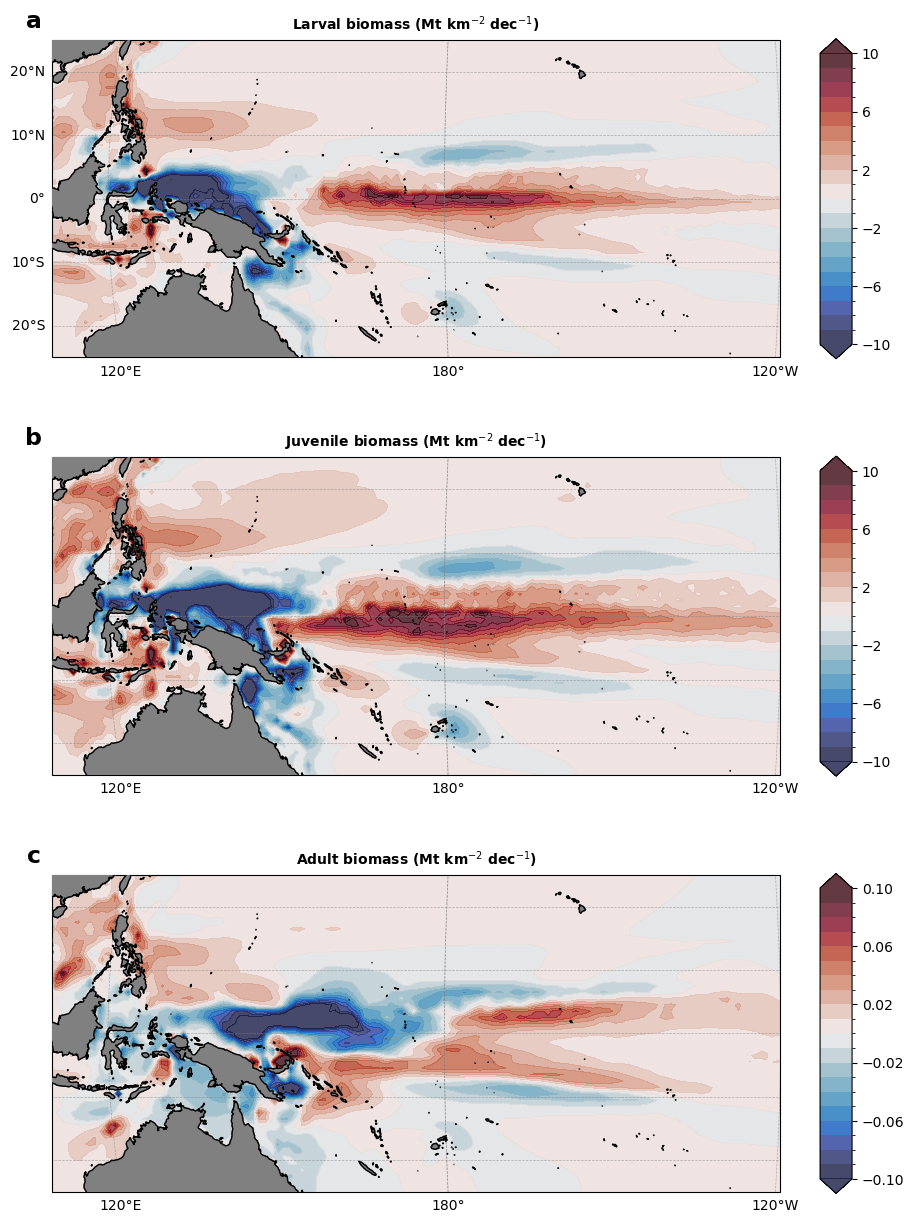

In [24]:
%%time

fslab = 15
fstic = 13

import matplotlib.lines as mlines
from cartopy.util import add_cyclic_point

proj = ccrs.Robinson(central_longitude=205)

colmap1 = lighten(cmo.balance, 0.8) #larvae
colmap2 = lighten(cmo.balance, 0.8) #juveniles
colmap3 = lighten(cmo.balance, 0.8) #adults

levs1 = np.arange(-10,11,1)
levs2 = np.arange(-10,11,1)
levs3 = np.arange(-10,11,1)*0.01

norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)
norm3 = mcolors.BoundaryNorm(levs3, ncolors=256)


fig = plt.figure(figsize=(10,16))
gs = GridSpec(3, 1)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[1,0], projection=proj)
ax3 = plt.subplot(gs[2,0], projection=proj)

p1 = ax1.contourf(lons, lats, larvae_trend, transform=ccrs.PlateCarree(), cmap=colmap1, norm=norm1, levels=levs1, extend='both')
p2 = ax2.contourf(lons, lats, juvenile_trend, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm2, levels=levs2, extend='both')
p3 = ax3.contourf(lons, lats, adult_trend, transform=ccrs.PlateCarree(), cmap=colmap3, norm=norm3, levels=levs3, extend='both')

ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)

xx = 0.5; yy = 1.05
plt.text(xx,yy, 'Larval biomass (Mt km$^{-2}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy, 'Juvenile biomass (Mt km$^{-2}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy, 'Adult biomass (Mt km$^{-2}$ dec$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax3.transAxes)

xx = -0.025
yy = 1.06
plt.text(xx,yy, 'a', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax3.transAxes)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.left_labels = False

ax1.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax2.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())
ax3.set_extent([110, 240, -25, 25], crs=ccrs.PlateCarree())

plt.subplots_adjust(wspace=0.15, hspace=0.05, left=0.1, right=0.9)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::4], fraction=0.04, aspect=10)
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::4], fraction=0.04, aspect=10)
cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::4], fraction=0.04, aspect=10)


In [25]:
fig.savefig("pearse_GAMs/figures/SEAPODYM_outputs_linear_trends.png", dpi=300)


## Undertake the decomposition at each grid cell across the ocean

In [37]:
%%time

from joblib import Parallel, delayed
from scipy.signal import periodogram, hilbert

# Setup CEEMDAN config
def make_ceemdan():
    ceemdan = CEEMDAN()
    ceemdan.noise_seed = 42
    ceemdan.num_siftings = 100
    ceemdan.Nstd = 0.2
    ceemdan.trials = 100
    return ceemdan

# Setup
years = np.arange(1958+0.5/12, 2022+11.51/12, 1/12)
times = sst.coords['time'].values
lats = sst.coords['lat'].values
lons = sst.coords['lon'].values

def find_imf_freq_Hilbert(imfs, years):
    inst_freqs = []
    for imf in imfs:
        analytic_signal = hilbert(imf)
        amplitude_envelope = np.abs(analytic_signal)
        instantaneous_phase = np.unwrap(np.angle(analytic_signal))
        instantaneous_frequency = np.diff(instantaneous_phase) / (2.0 * np.pi * np.diff(years))
        inst_freqs.append(instantaneous_frequency)
    return np.array([np.mean(freq) for freq in inst_freqs])


def find_weights_from_freqs(imfs, bands):
    fs = 12  # Hz (cycles per year)
    n_imfs, n_time = imfs.shape
    n_bands = len(bands)
    weights = np.zeros((n_bands, n_imfs))

    # find the frequency power spectra of the different IMFs
    freqs = []
    power = []
    for i in range(n_imfs):
        f, p = periodogram(imfs[i,:], fs=fs, scaling='density', window='hann')
        freqs.append(f)
        power.append(p)
    freqs = np.array(freqs); power = np.array(power)
    
    # find the weights associated with that power spectra
    for i in range(n_imfs):
        total_power = np.sum(power[i,:])
        for j, (f_min, f_max) in enumerate(bands):
            mask = (freqs[i,:] >= f_min) & (freqs[i,:] < f_max)
            band_power = np.sum(power[i][mask])
            weights[j, i] = band_power / total_power if total_power > 0 else 0.0

    return weights
    

def set_bands(imfs, weights):
    return weights @ imfs


def valid_signal(signal, tol=1e-12):
    if not np.all(np.isfinite(signal)):
        return False
    if np.nanstd(signal) < tol:
        return False
    return True


# Processing functions for each grid cell
def process_sst(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = sst_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_mld(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = mld_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_zeu(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = zeu_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_pp(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = pp_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_pp75(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = pp75_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_uo(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = uo_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_vo(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = vo_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_T_L1(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = T_L1_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_T_L2(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = T_L2_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_T_L3(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = T_L3_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_O2_L1(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = O2_L1_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_O2_L2(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = O2_L2_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_O2_L3(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = O2_L3_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_U_L1(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = U_L1_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_U_L2(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = U_L2_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_U_L3(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = U_L3_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_V_L1(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = V_L1_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_V_L2(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = V_L2_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_V_L3(ix, iy):
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    signal = V_L3_detr.isel(lon=ix, lat=iy).values
    if not np.all(np.isfinite(signal)):
        return (ix, iy, None)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)

def process_larvae(ix, iy):
    signal = larvae_detr.isel(lon=ix, lat=iy).values
    if not valid_signal(signal):
        return (ix, iy, None)
    ceemdan = make_ceemdan()
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_juvenile(ix, iy):
    signal = juvenile_detr.isel(lon=ix, lat=iy).values
    if not valid_signal(signal):
        return (ix, iy, None)
    ceemdan = make_ceemdan()
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)
def process_adult(ix, iy):
    signal = adult_detr.isel(lon=ix, lat=iy).values
    if not valid_signal(signal):
        return (ix, iy, None)
    ceemdan = make_ceemdan()  # Create fresh CEEMDAN instance (safe in parallel)
    try:
        imfs = ceemdan(signal)
        weights = find_weights_from_freqs(imfs, bands)
        grouped = set_bands(imfs, weights)
        return (ix, iy, grouped)
    except Exception as e:
        print(f"Error at ({ix}, {iy}): {e}")
        return (ix, iy, None)

CPU times: user 468 μs, sys: 102 μs, total: 570 μs
Wall time: 559 μs


## run the decomposition

In [38]:
%%time

# Predefined cut-offs for frequency bands
bands = [
    (1.0, np.inf),        # Subannual
    (0.15, 1.0),          # Interannual
    (0.01, 0.15),         # Decadal
    (-np.inf, 0.01)       # Centennial or more
]

# Coordinate pairs
ntime = len(times)
nlat = len(lats)
nlon = len(lons)
coords = [(ix, iy) for ix in range(nlon) for iy in range(nlat)]


CPU times: user 11.1 ms, sys: 2.27 ms, total: 13.4 ms
Wall time: 13.2 ms


In [36]:
%%time

# Run in parallel
sst_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_sst)(ix, iy) for (ix, iy) in coords
)

sst_imfs = np.zeros((4,len(times),len(lats),len(lons)))

# Assemble results
for ix, iy, grouped in sst_results:
    if grouped is not None:
        sst_imfs[:, :, iy, ix] = grouped

imfs_sst_ds = xr.Dataset(
    {
        "sst_imfs": (["IMF", "time", "lat", "lon"], sst_imfs),
        "sst_anom": (["time", "lat", "lon"], sst_anom.values),
        "sst_detr": (["time", "lat", "lon"], sst_detr.transpose("time", "lat", "lon").values),
        "sst_trend": (["lat", "lon"], sst_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_sst_ds

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
os.remove("SEAPODYM_imfs_sst_CEEMDAN.nc")
imfs_sst_ds.to_netcdf("SEAPODYM_imfs_sst_CEEMDAN.nc")


CPU times: user 1.14 s, sys: 794 ms, total: 1.93 s
Wall time: 1.94 s


In [13]:
%%time

mld_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_mld)(ix, iy) for (ix, iy) in coords
)
mld_imfs = np.zeros((4,len(times),len(lats),len(lons)))
for ix, iy, grouped in mld_results:
    if grouped is not None:
        mld_imfs[:, :, iy, ix] = grouped

imfs_mld_ds = xr.Dataset(
    {
        "mld_imfs": (["IMF", "time", "lat", "lon"], mld_imfs),
        "mld_anom": (["time", "lat", "lon"], mld_anom.values),
        "mld_detr": (["time", "lat", "lon"], mld_detr.transpose("time", "lat", "lon").values),
        "mld_trend": (["lat", "lon"], mld_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)


zeu_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_zeu)(ix, iy) for (ix, iy) in coords
)
zeu_imfs = np.zeros((4,len(times),len(lats),len(lons)))
for ix, iy, grouped in zeu_results:
    if grouped is not None:
        zeu_imfs[:, :, iy, ix] = grouped

imfs_zeu_ds = xr.Dataset(
    {
        "zeu_imfs": (["IMF", "time", "lat", "lon"], zeu_imfs),
        "zeu_anom": (["time", "lat", "lon"], zeu_anom.values),
        "zeu_detr": (["time", "lat", "lon"], zeu_detr.transpose("time", "lat", "lon").values),
        "zeu_trend": (["lat", "lon"], zeu_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
os.remove("SEAPODYM_imfs_mld_CEEMDAN.nc")
os.remove("SEAPODYM_imfs_zeu_CEEMDAN.nc")
imfs_mld_ds.to_netcdf("SEAPODYM_imfs_mld_CEEMDAN.nc")
imfs_zeu_ds.to_netcdf("SEAPODYM_imfs_zeu_CEEMDAN.nc")



[Parallel(n_jobs=112)]: Using backend LokyBackend with 112 concurrent workers.
[Parallel(n_jobs=112)]: Done 141 tasks      | elapsed:   21.5s
[Parallel(n_jobs=112)]: Done 424 tasks      | elapsed:   49.2s
[Parallel(n_jobs=112)]: Done 789 tasks      | elapsed:  1.5min
[Parallel(n_jobs=112)]: Done 1234 tasks      | elapsed:  2.4min
[Parallel(n_jobs=112)]: Done 1761 tasks      | elapsed:  3.7min
[Parallel(n_jobs=112)]: Done 2368 tasks      | elapsed:  5.0min
[Parallel(n_jobs=112)]: Done 3057 tasks      | elapsed:  7.0min
[Parallel(n_jobs=112)]: Done 3826 tasks      | elapsed:  9.3min
[Parallel(n_jobs=112)]: Done 4677 tasks      | elapsed: 11.8min
[Parallel(n_jobs=112)]: Done 5608 tasks      | elapsed: 14.3min
[Parallel(n_jobs=112)]: Done 6621 tasks      | elapsed: 16.9min
[Parallel(n_jobs=112)]: Done 7714 tasks      | elapsed: 20.0min
[Parallel(n_jobs=112)]: Done 8889 tasks      | elapsed: 22.8min
[Parallel(n_jobs=112)]: Done 10144 tasks      | elapsed: 26.1min
[Parallel(n_jobs=112)]: Don

CPU times: user 3min 36s, sys: 26.3 s, total: 4min 2s
Wall time: 3h 23min 21s


In [ ]:
%%time

pp_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_pp)(ix, iy) for (ix, iy) in coords
)

pp_imfs = np.zeros((4,len(times),len(lats),len(lons)))
for ix, iy, grouped in pp_results:
    if grouped is not None:
        pp_imfs[:, :, iy, ix] = grouped

imfs_pp_ds = xr.Dataset(
    {
        "pp_imfs": (["IMF", "time", "lat", "lon"], pp_imfs),
        "pp_anom": (["time", "lat", "lon"], pp_anom.values),
        "pp_detr": (["time", "lat", "lon"], pp_detr.transpose("time", "lat", "lon").values),
        "pp_trend": (["lat", "lon"], pp_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
os.remove("SEAPODYM_imfs_pp_CEEMDAN.nc")
imfs_pp_ds.to_netcdf("SEAPODYM_imfs_pp_CEEMDAN.nc")


[Parallel(n_jobs=112)]: Using backend LokyBackend with 112 concurrent workers.
[Parallel(n_jobs=112)]: Done 141 tasks      | elapsed:   21.7s
[Parallel(n_jobs=112)]: Done 424 tasks      | elapsed:   50.1s
[Parallel(n_jobs=112)]: Done 789 tasks      | elapsed:  1.5min


In [15]:
%%time

pp75_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_pp75)(ix, iy) for (ix, iy) in coords
)

pp75_imfs = np.zeros((4,len(times),len(lats),len(lons)))
for ix, iy, grouped in pp75_results:
    if grouped is not None:
        pp75_imfs[:, :, iy, ix] = grouped

imfs_pp75_ds = xr.Dataset(
    {
        "pp75_imfs": (["IMF", "time", "lat", "lon"], pp75_imfs),
        "pp75_anom": (["time", "lat", "lon"], pp75_anom.values),
        "pp75_detr": (["time", "lat", "lon"], pp75_detr.transpose("time", "lat", "lon").values),
        "pp75_trend": (["lat", "lon"], pp75_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_pp75_CEEMDAN.nc")
imfs_pp75_ds.to_netcdf("SEAPODYM_imfs_pp75_CEEMDAN.nc")

[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    5.8s
[Parallel(n_jobs=56)]: Done 253 tasks      | elapsed:   27.0s
[Parallel(n_jobs=56)]: Done 536 tasks      | elapsed:   52.0s
[Parallel(n_jobs=56)]: Done 901 tasks      | elapsed:  1.5min
[Parallel(n_jobs=56)]: Done 1346 tasks      | elapsed:  2.4min
[Parallel(n_jobs=56)]: Done 1873 tasks      | elapsed:  3.4min
[Parallel(n_jobs=56)]: Done 2480 tasks      | elapsed:  4.7min
[Parallel(n_jobs=56)]: Done 3169 tasks      | elapsed:  6.6min
[Parallel(n_jobs=56)]: Done 3938 tasks      | elapsed:  8.7min
[Parallel(n_jobs=56)]: Done 4789 tasks      | elapsed: 11.2min
[Parallel(n_jobs=56)]: Done 5720 tasks      | elapsed: 13.7min
[Parallel(n_jobs=56)]: Done 6733 tasks      | elapsed: 16.4min
/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/PyEMD/CEEMDAN.py:210: RuntimeWarning: invalid value encountered in divide
  S = S / scale_s
/g/d

NameError: name 'imfs_pp_ds' is not defined

In [15]:
%%time

uo_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_uo)(ix, iy) for (ix, iy) in coords
)

uo_imfs = np.zeros((4,len(times),len(lats),len(lons)))

# Assemble results
for ix, iy, grouped in uo_results:
    if grouped is not None:
        uo_imfs[:, :, iy, ix] = grouped

imfs_uo_ds = xr.Dataset(
    {
        "uo_imfs": (["IMF", "time", "lat", "lon"], uo_imfs),
        "uo_anom": (["time", "lat", "lon"], uo_anom.values),
        "uo_detr": (["time", "lat", "lon"], uo_detr.transpose("time", "lat", "lon").values),
        "uo_trend": (["lat", "lon"], uo_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
os.remove("SEAPODYM_imfs_uo_CEEMDAN.nc")
imfs_uo_ds.to_netcdf("SEAPODYM_imfs_uo_CEEMDAN.nc")


[Parallel(n_jobs=112)]: Using backend LokyBackend with 112 concurrent workers.
[Parallel(n_jobs=112)]: Done 141 tasks      | elapsed:    1.9s
[Parallel(n_jobs=112)]: Done 424 tasks      | elapsed:   35.6s
[Parallel(n_jobs=112)]: Done 789 tasks      | elapsed:  1.1min
[Parallel(n_jobs=112)]: Done 1234 tasks      | elapsed:  2.0min
[Parallel(n_jobs=112)]: Done 1761 tasks      | elapsed:  3.0min
[Parallel(n_jobs=112)]: Done 2368 tasks      | elapsed:  4.3min
[Parallel(n_jobs=112)]: Done 3057 tasks      | elapsed:  6.0min
[Parallel(n_jobs=112)]: Done 3826 tasks      | elapsed:  8.1min
[Parallel(n_jobs=112)]: Done 4677 tasks      | elapsed: 10.4min
[Parallel(n_jobs=112)]: Done 5608 tasks      | elapsed: 12.8min
[Parallel(n_jobs=112)]: Done 6621 tasks      | elapsed: 15.2min
[Parallel(n_jobs=112)]: Done 7714 tasks      | elapsed: 18.0min
[Parallel(n_jobs=112)]: Done 8889 tasks      | elapsed: 20.6min
[Parallel(n_jobs=112)]: Done 10144 tasks      | elapsed: 23.7min
[Parallel(n_jobs=112)]: Don

CPU times: user 3min 41s, sys: 23.9 s, total: 4min 5s
Wall time: 3h 6min 20s


In [ ]:
%%time

vo_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_vo)(ix, iy) for (ix, iy) in coords
)

vo_imfs = np.zeros((4,len(times),len(lats),len(lons)))

# Assemble results
for ix, iy, grouped in vo_results:
    if grouped is not None:
        vo_imfs[:, :, iy, ix] = grouped

imfs_vo_ds = xr.Dataset(
    {
        "vo_imfs": (["IMF", "time", "lat", "lon"], vo_imfs),
        "vo_anom": (["time", "lat", "lon"], vo_anom.values),
        "vo_detr": (["time", "lat", "lon"], vo_detr.transpose("time", "lat", "lon").values),
        "vo_trend": (["lat", "lon"], vo_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
os.remove("SEAPODYM_imfs_vo_CEEMDAN.nc")
imfs_vo_ds.to_netcdf("SEAPODYM_imfs_vo_CEEMDAN.nc")


In [ ]:
%%time

T_L1_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_T_L1)(ix, iy) for (ix, iy) in coords
)
T_L2_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_T_L2)(ix, iy) for (ix, iy) in coords
)
T_L3_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_T_L3)(ix, iy) for (ix, iy) in coords
)

T_L1_imfs = np.zeros((4,len(times),len(lats),len(lons)))
T_L2_imfs = np.zeros((4,len(times),len(lats),len(lons)))
T_L3_imfs = np.zeros((4,len(times),len(lats),len(lons)))


# Assemble results
for ix, iy, grouped in T_L1_results:
    if grouped is not None:
        T_L1_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in T_L2_results:
    if grouped is not None:
        T_L2_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in T_L3_results:
    if grouped is not None:
        T_L3_imfs[:, :, iy, ix] = grouped

imfs_T_L1_ds = xr.Dataset(
    {
        "T_L1_imfs": (["IMF", "time", "lat", "lon"], T_L1_imfs),
        "T_L1_anom": (["time", "lat", "lon"], T_L1_anom.values),
        "T_L1_detr": (["time", "lat", "lon"], T_L1_detr.transpose("time", "lat", "lon").values),
        "T_L1_trend": (["lat", "lon"], T_L1_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_T_L2_ds = xr.Dataset(
    {
        "T_L2_imfs": (["IMF", "time", "lat", "lon"], T_L2_imfs),
        "T_L2_anom": (["time", "lat", "lon"], T_L2_anom.values),
        "T_L2_detr": (["time", "lat", "lon"], T_L2_detr.transpose("time", "lat", "lon").values),
        "T_L2_trend": (["lat", "lon"], T_L2_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_T_L3_ds = xr.Dataset(
    {
        "T_L3_imfs": (["IMF", "time", "lat", "lon"], T_L3_imfs),
        "T_L3_anom": (["time", "lat", "lon"], T_L3_anom.values),
        "T_L3_detr": (["time", "lat", "lon"], T_L3_detr.transpose("time", "lat", "lon").values),
        "T_L3_trend": (["lat", "lon"], T_L3_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_T_L1_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_T_L2_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_T_L3_CEEMDAN.nc")

imfs_T_L1_ds.to_netcdf("SEAPODYM_imfs_T_L1_CEEMDAN.nc")
imfs_T_L2_ds.to_netcdf("SEAPODYM_imfs_T_L2_CEEMDAN.nc")
imfs_T_L3_ds.to_netcdf("SEAPODYM_imfs_T_L3_CEEMDAN.nc")

        

[Parallel(n_jobs=112)]: Using backend LokyBackend with 112 concurrent workers.
[Parallel(n_jobs=112)]: Done 141 tasks      | elapsed:   21.7s
[Parallel(n_jobs=112)]: Done 424 tasks      | elapsed:   44.1s
[Parallel(n_jobs=112)]: Done 789 tasks      | elapsed:  1.4min
[Parallel(n_jobs=112)]: Done 1234 tasks      | elapsed:  2.2min
[Parallel(n_jobs=112)]: Done 1761 tasks      | elapsed:  3.3min
[Parallel(n_jobs=112)]: Done 2368 tasks      | elapsed:  4.5min
[Parallel(n_jobs=112)]: Done 3057 tasks      | elapsed:  6.3min
[Parallel(n_jobs=112)]: Done 3826 tasks      | elapsed:  8.4min
[Parallel(n_jobs=112)]: Done 4677 tasks      | elapsed: 10.8min
[Parallel(n_jobs=112)]: Done 5608 tasks      | elapsed: 13.2min
[Parallel(n_jobs=112)]: Done 6621 tasks      | elapsed: 15.6min
[Parallel(n_jobs=112)]: Done 7714 tasks      | elapsed: 18.5min
[Parallel(n_jobs=112)]: Done 8889 tasks      | elapsed: 21.1min
[Parallel(n_jobs=112)]: Done 10144 tasks      | elapsed: 24.2min
[Parallel(n_jobs=112)]: Don

In [18]:
%%time

U_L1_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_U_L1)(ix, iy) for (ix, iy) in coords
)
U_L2_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_U_L2)(ix, iy) for (ix, iy) in coords
)
U_L3_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_U_L3)(ix, iy) for (ix, iy) in coords
)

U_L1_imfs = np.zeros((4,len(times),len(lats),len(lons)))
U_L2_imfs = np.zeros((4,len(times),len(lats),len(lons)))
U_L3_imfs = np.zeros((4,len(times),len(lats),len(lons)))


# Assemble results
for ix, iy, grouped in U_L1_results:
    if grouped is not None:
        U_L1_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in U_L2_results:
    if grouped is not None:
        U_L2_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in U_L3_results:
    if grouped is not None:
        U_L3_imfs[:, :, iy, ix] = grouped

imfs_U_L1_ds = xr.Dataset(
    {
        "U_L1_imfs": (["IMF", "time", "lat", "lon"], U_L1_imfs),
        "U_L1_anom": (["time", "lat", "lon"], U_L1_anom.values),
        "U_L1_detr": (["time", "lat", "lon"], U_L1_detr.transpose("time", "lat", "lon").values),
        "U_L1_trend": (["lat", "lon"], U_L1_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_U_L2_ds = xr.Dataset(
    {
        "U_L2_imfs": (["IMF", "time", "lat", "lon"], U_L2_imfs),
        "U_L2_anom": (["time", "lat", "lon"], U_L2_anom.values),
        "U_L2_detr": (["time", "lat", "lon"], U_L2_detr.transpose("time", "lat", "lon").values),
        "U_L2_trend": (["lat", "lon"], U_L2_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_U_L3_ds = xr.Dataset(
    {
        "U_L3_imfs": (["IMF", "time", "lat", "lon"], U_L3_imfs),
        "U_L3_anom": (["time", "lat", "lon"], U_L3_anom.values),
        "U_L3_detr": (["time", "lat", "lon"], U_L3_detr.transpose("time", "lat", "lon").values),
        "U_L3_trend": (["lat", "lon"], U_L3_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_U_L1_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_U_L2_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_U_L3_CEEMDAN.nc")

imfs_U_L1_ds.to_netcdf("SEAPODYM_imfs_U_L1_CEEMDAN.nc")
imfs_U_L2_ds.to_netcdf("SEAPODYM_imfs_U_L2_CEEMDAN.nc")
imfs_U_L3_ds.to_netcdf("SEAPODYM_imfs_U_L3_CEEMDAN.nc")



[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.3s
[Parallel(n_jobs=56)]: Done 253 tasks      | elapsed:   21.0s
[Parallel(n_jobs=56)]: Done 536 tasks      | elapsed:   43.3s
[Parallel(n_jobs=56)]: Done 901 tasks      | elapsed:  1.3min
[Parallel(n_jobs=56)]: Done 1346 tasks      | elapsed:  2.2min
[Parallel(n_jobs=56)]: Done 1873 tasks      | elapsed:  3.2min
[Parallel(n_jobs=56)]: Done 2480 tasks      | elapsed:  4.4min
[Parallel(n_jobs=56)]: Done 3169 tasks      | elapsed:  6.2min
[Parallel(n_jobs=56)]: Done 3938 tasks      | elapsed:  8.2min
[Parallel(n_jobs=56)]: Done 4789 tasks      | elapsed: 10.5min
[Parallel(n_jobs=56)]: Done 5720 tasks      | elapsed: 12.7min
[Parallel(n_jobs=56)]: Done 6733 tasks      | elapsed: 15.2min
[Parallel(n_jobs=56)]: Done 7826 tasks      | elapsed: 17.9min
[Parallel(n_jobs=56)]: Done 9001 tasks      | elapsed: 20.4min
[Parallel(n_jobs=56)]: Done 10256 tasks      

CPU times: user 4min 58s, sys: 29 s, total: 5min 27s
Wall time: 4h 22min 58s


In [19]:
%%time

V_L1_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_V_L1)(ix, iy) for (ix, iy) in coords
)
V_L2_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_V_L2)(ix, iy) for (ix, iy) in coords
)
V_L3_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_V_L3)(ix, iy) for (ix, iy) in coords
)

V_L1_imfs = np.zeros((4,len(times),len(lats),len(lons)))
V_L2_imfs = np.zeros((4,len(times),len(lats),len(lons)))
V_L3_imfs = np.zeros((4,len(times),len(lats),len(lons)))


# Assemble results
for ix, iy, grouped in V_L1_results:
    if grouped is not None:
        V_L1_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in V_L2_results:
    if grouped is not None:
        V_L2_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in V_L3_results:
    if grouped is not None:
        V_L3_imfs[:, :, iy, ix] = grouped

imfs_V_L1_ds = xr.Dataset(
    {
        "V_L1_imfs": (["IMF", "time", "lat", "lon"], V_L1_imfs),
        "V_L1_anom": (["time", "lat", "lon"], V_L1_anom.values),
        "V_L1_detr": (["time", "lat", "lon"], V_L1_detr.transpose("time", "lat", "lon").values),
        "V_L1_trend": (["lat", "lon"], V_L1_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_V_L2_ds = xr.Dataset(
    {
        "V_L2_imfs": (["IMF", "time", "lat", "lon"], V_L2_imfs),
        "V_L2_anom": (["time", "lat", "lon"], V_L2_anom.values),
        "V_L2_detr": (["time", "lat", "lon"], V_L2_detr.transpose("time", "lat", "lon").values),
        "V_L2_trend": (["lat", "lon"], V_L2_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_V_L3_ds = xr.Dataset(
    {
        "V_L3_imfs": (["IMF", "time", "lat", "lon"], V_L3_imfs),
        "V_L3_anom": (["time", "lat", "lon"], V_L3_anom.values),
        "V_L3_detr": (["time", "lat", "lon"], V_L3_detr.transpose("time", "lat", "lon").values),
        "V_L3_trend": (["lat", "lon"], V_L3_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_V_L1_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_V_L2_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_V_L3_CEEMDAN.nc")

imfs_V_L1_ds.to_netcdf("SEAPODYM_imfs_V_L1_CEEMDAN.nc")
imfs_V_L2_ds.to_netcdf("SEAPODYM_imfs_V_L2_CEEMDAN.nc")
imfs_V_L3_ds.to_netcdf("SEAPODYM_imfs_V_L3_CEEMDAN.nc")



[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.5s
[Parallel(n_jobs=56)]: Done 253 tasks      | elapsed:   19.8s
[Parallel(n_jobs=56)]: Done 536 tasks      | elapsed:   42.7s
[Parallel(n_jobs=56)]: Done 901 tasks      | elapsed:  1.3min
[Parallel(n_jobs=56)]: Done 1346 tasks      | elapsed:  2.2min
[Parallel(n_jobs=56)]: Done 1873 tasks      | elapsed:  3.1min
[Parallel(n_jobs=56)]: Done 2480 tasks      | elapsed:  4.4min
[Parallel(n_jobs=56)]: Done 3169 tasks      | elapsed:  6.1min
[Parallel(n_jobs=56)]: Done 3938 tasks      | elapsed:  8.2min
[Parallel(n_jobs=56)]: Done 4789 tasks      | elapsed: 10.5min
[Parallel(n_jobs=56)]: Done 5720 tasks      | elapsed: 12.7min
[Parallel(n_jobs=56)]: Done 6733 tasks      | elapsed: 15.1min
[Parallel(n_jobs=56)]: Done 7826 tasks      | elapsed: 17.9min
[Parallel(n_jobs=56)]: Done 9001 tasks      | elapsed: 20.4min
[Parallel(n_jobs=56)]: Done 10256 tasks      

CPU times: user 5min 4s, sys: 29.3 s, total: 5min 33s
Wall time: 4h 23min 3s


In [ ]:
%%time


O2_L1_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_O2_L1)(ix, iy) for (ix, iy) in coords
)
O2_L2_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_O2_L2)(ix, iy) for (ix, iy) in coords
)
O2_L3_results = Parallel(n_jobs=112, backend='loky', verbose=2)(
    delayed(process_O2_L3)(ix, iy) for (ix, iy) in coords
)

O2_L1_imfs = np.zeros((4,len(times),len(lats),len(lons)))
O2_L2_imfs = np.zeros((4,len(times),len(lats),len(lons)))
O2_L3_imfs = np.zeros((4,len(times),len(lats),len(lons)))

# Assemble results
for ix, iy, grouped in O2_L1_results:
    if grouped is not None:
        O2_L1_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in O2_L2_results:
    if grouped is not None:
        O2_L2_imfs[:, :, iy, ix] = grouped
for ix, iy, grouped in O2_L3_results:
    if grouped is not None:
        O2_L3_imfs[:, :, iy, ix] = grouped


imfs_O2_L1_ds = xr.Dataset(
    {
        "O2_L1_imfs": (["IMF", "time", "lat", "lon"], O2_L1_imfs),
        "O2_L1_anom": (["time", "lat", "lon"], O2_L1_anom.values),
        "O2_L1_detr": (["time", "lat", "lon"], O2_L1_detr.transpose("time", "lat", "lon").values),
        "O2_L1_trend": (["lat", "lon"], O2_L1_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_O2_L2_ds = xr.Dataset(
    {
        "O2_L2_imfs": (["IMF", "time", "lat", "lon"], O2_L2_imfs),
        "O2_L2_anom": (["time", "lat", "lon"], O2_L2_anom.values),
        "O2_L2_detr": (["time", "lat", "lon"], O2_L2_detr.transpose("time", "lat", "lon").values),
        "O2_L2_trend": (["lat", "lon"], O2_L2_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_O2_L3_ds = xr.Dataset(
    {
        "O2_L3_imfs": (["IMF", "time", "lat", "lon"], O2_L3_imfs),
        "O2_L3_anom": (["time", "lat", "lon"], O2_L3_anom.values),
        "O2_L3_detr": (["time", "lat", "lon"], O2_L3_detr.transpose("time", "lat", "lon").values),
        "O2_L3_trend": (["lat", "lon"], O2_L3_trend.values),
    },
    coords={
        "IMF": np.arange(1,5,1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_O2_L1_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_O2_L2_CEEMDAN.nc")
#os.remove("SEAPODYM_imfs_O2_L3_CEEMDAN.nc")

imfs_O2_L1_ds.to_netcdf("SEAPODYM_imfs_O2_L1_CEEMDAN.nc")
imfs_O2_L2_ds.to_netcdf("SEAPODYM_imfs_O2_L2_CEEMDAN.nc")
imfs_O2_L3_ds.to_netcdf("SEAPODYM_imfs_O2_L3_CEEMDAN.nc")


[Parallel(n_jobs=112)]: Using backend LokyBackend with 112 concurrent workers.


In [40]:
print(np.shape(larvae_imfs))
print(np.shape(larvae_detr))
print(len(larvae.coords['time']))
print(sst)

(4, 780, 120, 260)
(120, 260, 756)
756
<xarray.DataArray 'sst' (time: 780, lat: 120, lon: 260)> Size: 97MB
[24336000 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 2kB 30.5 31.5 32.5 33.5 ... 286.5 287.5 288.5 289.5
  * lat      (lat) float64 960B -58.5 -57.5 -56.5 -55.5 ... 57.5 58.5 59.5 60.5
  * time     (time) datetime64[ns] 6kB 1958-01-15 1958-02-15 ... 2022-12-15
Attributes:
    units:    degree_Celsius


In [41]:
%%time

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(invalid="ignore", divide="ignore")

# Run in parallel
larvae_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_larvae)(ix, iy) for (ix, iy) in coords
)



larvae_imfs = np.zeros((4, len(larvae.coords['time']), len(lats), len(lons)))

# Assemble results
for ix, iy, grouped in larvae_results:
    if grouped is not None:
        larvae_imfs[:, :, iy, ix] = grouped

imfs_larvae_ds = xr.Dataset(
    {
        "larvae_imfs": (["IMF", "time", "lat", "lon"], larvae_imfs),
        "larvae_anom": (["time", "lat", "lon"], larvae_anom.values),
        "larvae_detr": (["time", "lat", "lon"], larvae_detr.transpose("time", "lat", "lon").values),
        "larvae_trend": (["lat", "lon"], larvae_trend.values),
    },
    coords={
        "IMF": np.arange(1, 5, 1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_larvae_ds

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_larvae_CEEMDAN.nc")
imfs_larvae_ds.to_netcdf("SEAPODYM_imfs_larvae_CEEMDAN.nc")


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    7.7s
[Parallel(n_jobs=56)]: Done 253 tasks      | elapsed:   15.5s
[Parallel(n_jobs=56)]: Done 536 tasks      | elapsed:   29.5s
[Parallel(n_jobs=56)]: Done 901 tasks      | elapsed:   52.9s
[Parallel(n_jobs=56)]: Done 1346 tasks      | elapsed:  1.6min
[Parallel(n_jobs=56)]: Done 1873 tasks      | elapsed:  2.4min
[Parallel(n_jobs=56)]: Done 2480 tasks      | elapsed:  3.6min
[Parallel(n_jobs=56)]: Done 3169 tasks      | elapsed:  5.4min
[Parallel(n_jobs=56)]: Done 3938 tasks      | elapsed:  7.5min
[Parallel(n_jobs=56)]: Done 4789 tasks      | elapsed:  9.9min
[Parallel(n_jobs=56)]: Done 5720 tasks      | elapsed: 12.1min
[Parallel(n_jobs=56)]: Done 6733 tasks      | elapsed: 14.7min
[Parallel(n_jobs=56)]: Done 7826 tasks      | elapsed: 17.6min
[Parallel(n_jobs=56)]: Done 9001 tasks      | elapsed: 20.1min
[Parallel(n_jobs=56)]: Done 10256 tasks      

CPU times: user 1min 42s, sys: 10.2 s, total: 1min 53s
Wall time: 1h 26min 19s


In [42]:
%%time

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(invalid="ignore", divide="ignore")

# Run in parallel
juvenile_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_juvenile)(ix, iy) for (ix, iy) in coords
)

juvenile_imfs = np.zeros((4, len(juvenile.coords['time']), len(lats), len(lons)))

# Assemble results
for ix, iy, grouped in juvenile_results:
    if grouped is not None:
        juvenile_imfs[:, :, iy, ix] = grouped

imfs_juvenile_ds = xr.Dataset(
    {
        "juvenile_imfs": (["IMF", "time", "lat", "lon"], juvenile_imfs),
        "juvenile_anom": (["time", "lat", "lon"], juvenile_anom.values),
        "juvenile_detr": (["time", "lat", "lon"], juvenile_detr.transpose("time", "lat", "lon").values),
        "juvenile_trend": (["lat", "lon"], juvenile_trend.values),
    },
    coords={
        "IMF": np.arange(1, 5, 1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_juvenile_ds

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_juvenile_CEEMDAN.nc")
imfs_juvenile_ds.to_netcdf("SEAPODYM_imfs_juvenile_CEEMDAN.nc")



[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.4s
[Parallel(n_jobs=56)]: Done 405 tasks      | elapsed:    6.4s
[Parallel(n_jobs=56)]: Done 801 tasks      | elapsed:   41.3s
[Parallel(n_jobs=56)]: Done 1180 tasks      | elapsed:  1.1min
[Parallel(n_jobs=56)]: Done 1626 tasks      | elapsed:  1.8min
[Parallel(n_jobs=56)]: Done 2153 tasks      | elapsed:  2.7min
[Parallel(n_jobs=56)]: Done 2760 tasks      | elapsed:  4.0min
[Parallel(n_jobs=56)]: Done 3449 tasks      | elapsed:  5.6min
[Parallel(n_jobs=56)]: Done 4218 tasks      | elapsed:  7.7min
[Parallel(n_jobs=56)]: Done 5069 tasks      | elapsed:  9.9min
[Parallel(n_jobs=56)]: Done 6000 tasks      | elapsed: 11.9min
[Parallel(n_jobs=56)]: Done 7013 tasks      | elapsed: 14.3min
[Parallel(n_jobs=56)]: Done 8106 tasks      | elapsed: 16.8min
[Parallel(n_jobs=56)]: Done 9281 tasks      | elapsed: 19.2min
[Parallel(n_jobs=56)]: Done 10536 tasks     

CPU times: user 1min 43s, sys: 9.78 s, total: 1min 53s
Wall time: 1h 21min 19s


In [43]:
%%time

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(invalid="ignore", divide="ignore")

# Run in parallel
adult_results = Parallel(n_jobs=56, backend='loky', verbose=2)(
    delayed(process_adult)(ix, iy) for (ix, iy) in coords
)

adult_imfs = np.zeros((4, len(adult.coords['time']), len(lats), len(lons)))

# Assemble results
for ix, iy, grouped in adult_results:
    if grouped is not None:
        adult_imfs[:, :, iy, ix] = grouped

imfs_adult_ds = xr.Dataset(
    {
        "adult_imfs": (["IMF", "time", "lat", "lon"], adult_imfs),
        "adult_anom": (["time", "lat", "lon"], adult_anom.values),
        "adult_detr": (["time", "lat", "lon"], adult_detr.transpose("time", "lat", "lon").values),
        "adult_trend": (["lat", "lon"], adult_trend.values),
    },
    coords={
        "IMF": np.arange(1, 5, 1),
        "time": dates,
        "lat": lats,
        "lon": lons,
    },
)
imfs_adult_ds

os.chdir(wrkdir + "/pearse_GAMs/EMD_forcings/")
#os.remove("SEAPODYM_imfs_adult_CEEMDAN.nc")
imfs_adult_ds.to_netcdf("SEAPODYM_imfs_adult_CEEMDAN.nc")


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.3s
[Parallel(n_jobs=56)]: Done 406 tasks      | elapsed:    6.9s
[Parallel(n_jobs=56)]: Done 798 tasks      | elapsed:   46.5s
[Parallel(n_jobs=56)]: Done 1181 tasks      | elapsed:  1.2min
[Parallel(n_jobs=56)]: Done 1626 tasks      | elapsed:  2.0min
[Parallel(n_jobs=56)]: Done 2153 tasks      | elapsed:  3.0min
[Parallel(n_jobs=56)]: Done 2760 tasks      | elapsed:  4.4min
[Parallel(n_jobs=56)]: Done 3449 tasks      | elapsed:  6.1min
[Parallel(n_jobs=56)]: Done 4218 tasks      | elapsed:  8.5min
[Parallel(n_jobs=56)]: Done 5069 tasks      | elapsed: 10.9min
[Parallel(n_jobs=56)]: Done 6000 tasks      | elapsed: 13.1min
[Parallel(n_jobs=56)]: Done 7013 tasks      | elapsed: 15.8min
[Parallel(n_jobs=56)]: Done 8106 tasks      | elapsed: 18.6min
[Parallel(n_jobs=56)]: Done 9281 tasks      | elapsed: 21.1min
[Parallel(n_jobs=56)]: Done 10536 tasks     

CPU times: user 1min 43s, sys: 10.4 s, total: 1min 54s
Wall time: 1h 29min 22s
